In [1]:
### 03_유방암 판정을 위한 모델을 구축

In [2]:
# 처리패턴과 개발 순서를 실습

# 의학에서 최종 진단은 어디까지나 의사의 몫이지만, 이런 모델이 있으면 의사가 자신의 판단이 옳았는지 확인해 볼 수 있음
# 이렇게 인간의 판단을 보조하는 역할도 머신러닝 모델을 의미있게 활용하는 한 가지 형태

In [3]:
# 1. 데이터

In [4]:
# 실습에 사용할 데이터 집합은 Breast Cancer Wisconsin (Diagnostic) dataset (유방암 진단 데이터 집합)
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
# 유방암 검진에서 종양이 발견된 환자의 종양 세포를 채취하고 이를 현미경으로 분석한 결과를 수치화한 정보로 구성된 데이터.
# 구체적으로 개개의 세포에 대해 다음 10개의 특징값이 수치화.
#
# a) 반지름 (세포 중심에서 주위까지의 평균 거리)
# b) 텍스처 (그레이스케일 값의 표준편차)
# c) 둘레 길이
# d) 면적
# e) 평활도 (반지름의 국소적인 변화 정도)
# f) 콤팩트도 (둘레^2/면적 - 1.0)
# g) 오목 면 (윤각선 중 오목 면의 비율)
# h) 오목 점 (윤각선에 포함된 오목 면의 수)
# i) 대칭성
# j) 프랙탈도 (해안선 근사 - 1)
#
# 그 다음에는 각 특징값에 통계처리를 거쳐 평균, 표준편차, 최댓값의 세 가지 통계값을 계산.
# 그 결과 정밀검사 대상 환자에 대해 10 * 3 = 30 이라는 수치가 계산.
# 이 30개 필드(차원)의 데이터가 이 환자가 가진 종양의 악성 malignant / 양성 benign 여부와 함께 공개된 데이터 집합으로 배포.
# 배포 데이터 집합에서는 악성이 0, 양성이 1로 표현.
#
# 정밀 검사 데이터를 입력해 진단 결과를 예측하는 모델을 만드는 것이 목적.
# 적용되는 업무가 의료인 만큼, 모델이 의사를 완전히 대체하기에는 현실적으로 어렵겠지만,
# 의사의 진단을 돕는 보조적인 역할은 가능.


In [5]:
# 2. 구현하기

In [6]:
# 1) 공통 코드

In [7]:
# 공통 처리

# 불필요한 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 글꼴 설정
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='batang')

# 그래프 글꼴 크기 설정
plt.rcParams['font.size'] = 14

# 데이터프레임 출력용 함수
from IPython.display import display

# 숫자 출력 조정
# 넘파이 부동소수점 출력 자리수 설정
np.set_printoptions(suppress=True, precision=4)

# 판다스 부동소수점 출력 자리수 설정
pd.options.display.float_format = '{:.4f}'.format

# 데이터프레임 모든 필드 출력
pd.set_option('display.max_columns', None)

# 난수 시드
random_seed = 123

In [8]:
# 2) 데이터 읽어 들이기

# 사이킷런 라이브러리를 임포트
# 사이킷런은 머신러닝에서 가장 널리 사용되는 라이브러리로 여러 모델을 구현하는데 사용.
# 모델 생성뿐만 아니라 데이터 전처리, 모델 평가 등 다양한 용도로 사용.
# 부가 기능으로 머신러닝에서 자주 사용되는 데이터를 함수 호출만으로 받아올 수 있는 기능이 있음.

# 유방암 데이터 집합
# UCI 대데이터 집합 배포 웹사이트 : https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)
# 유방암 데이터 집합 읽어 들이기

In [9]:
# 라이브러리 임포트
from sklearn.datasets import load_breast_cancer

In [10]:
# 데이터 내려받기
cancer = load_breast_cancer()

In [11]:
# 데이터에 대한 설명 읽기
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [12]:
cancer.data

array([[ 17.99  ,  10.38  , 122.8   , ...,   0.2654,   0.4601,   0.1189],
       [ 20.57  ,  17.77  , 132.9   , ...,   0.186 ,   0.275 ,   0.089 ],
       [ 19.69  ,  21.25  , 130.    , ...,   0.243 ,   0.3613,   0.0876],
       ...,
       [ 16.6   ,  28.08  , 108.3   , ...,   0.1418,   0.2218,   0.0782],
       [ 20.6   ,  29.33  , 140.1   , ...,   0.265 ,   0.4087,   0.124 ],
       [  7.76  ,  24.54  ,  47.92  , ...,   0.    ,   0.2871,   0.0704]],
      shape=(569, 30))

In [14]:
type(cancer.data)

numpy.ndarray

In [13]:
# 읽어 들인 데이터를 데이터프레임으로 변환하기
# 데이터프레임으로 변환하면 그 뒤에 해야 하는 1) 데이터 확인, 2) 데이터 전처리 과정이 간단해짐
# 데이터프레임으로 변환하기

In [15]:
# 읽기 쉽게 한글로 컬럼이름 지정
columns = [
    '반지름_평균', '텍스처_평균', '둘레길이_평균', '면적_평균', '평활도_평균',
    '콤팩트도_평균', '오목면_평균', '오목점_평균', '대칭성_평균', '프랙탈도_평균',
    '반지름_표준편차', '텍스처_표준편차', '둘레길이_표준편차', '면적_표준편차', '평활도_표준편차',
    '콤팩트도_표준편차', '오목면_표준편차', '오목점_표준편차', '대칭성_표준편차', '프랙탈도_표준편차',
    '반지름_최대', '텍스처_최대', '둘레길이_최대', '면적_최대', '평활도_최대',
    '콤팩트도_최대', '오목면_최대', '오목점_최대', '대칭성_최대', '프랙탈도_최대'
]

df = pd.DataFrame(cancer.data, columns=columns)
df.head()

,반지름_평균,텍스처_평균,둘레길이_평균,면적_평균,평활도_평균,콤팩트도_평균,오목면_평균,오목점_평균,대칭성_평균,프랙탈도_평균,반지름_표준편차,텍스처_표준편차,둘레길이_표준편차,면적_표준편차,평활도_표준편차,콤팩트도_표준편차,오목면_표준편차,오목점_표준편차,대칭성_표준편차,프랙탈도_표준편차,반지름_최대,텍스처_최대,둘레길이_최대,면적_최대,평활도_최대,콤팩트도_최대,오목면_최대,오목점_최대,대칭성_최대,프랙탈도_최대
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   반지름_평균     569 non-null    float64
 1   텍스처_평균     569 non-null    float64
 2   둘레길이_평균    569 non-null    float64
 3   면적_평균      569 non-null    float64
 4   평활도_평균     569 non-null    float64
 5   콤팩트도_평균    569 non-null    float64
 6   오목면_평균     569 non-null    float64
 7   오목점_평균     569 non-null    float64
 8   대칭성_평균     569 non-null    float64
 9   프랙탈도_평균    569 non-null    float64
 10  반지름_표준편차   569 non-null    float64
 11  텍스처_표준편차   569 non-null    float64
 12  둘레길이_표준편차  569 non-null    float64
 13  면적_표준편차    569 non-null    float64
 14  평활도_표준편차   569 non-null    float64
 15  콤팩트도_표준편차  569 non-null    float64
 16  오목면_표준편차   569 non-null    float64
 17  오목점_표준편차   569 non-null    float64
 18  대칭성_표준편차   569 non-null    float64
 19  프랙탈도_표준편차  569 non-null    float64
 20  반지름_최대    

In [17]:
cancer.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [18]:
# 정답 데이터를 꺼냄
# cancer.target의 포멧은 넘파이이고, 값이 0인것과 1인것을 세어야 하므로 판다스의 시리즈 객체로 변환
y = pd.Series(cancer.target)

In [19]:
# 3) 데이터 확인

In [20]:
# 1. 입력 데이터(df)와 정답 데이터(y)의 일부를 화면에 출력

# 입력 데이터를 화면에 출력하기

# 입력 데이터의 20번째 줄부터 24번째 줄까지 화면에 출력
df[20:25]

,반지름_평균,텍스처_평균,둘레길이_평균,면적_평균,평활도_평균,콤팩트도_평균,오목면_평균,오목점_평균,대칭성_평균,프랙탈도_평균,반지름_표준편차,텍스처_표준편차,둘레길이_표준편차,면적_표준편차,평활도_표준편차,콤팩트도_표준편차,오목면_표준편차,오목점_표준편차,대칭성_표준편차,프랙탈도_표준편차,반지름_최대,텍스처_최대,둘레길이_최대,면적_최대,평활도_최대,콤팩트도_최대,오목면_최대,오목점_최대,대칭성_최대,프랙탈도_최대
20,13.0800,15.7100,85.6300,520.0000,0.1075,0.1270,0.0457,0.0311,0.1967,0.0681,0.1852,0.7477,1.3830,14.6700,0.0041,0.0190,0.0170,0.0065,0.0168,0.0024,14.5000,20.4900,96.0900,630.5000,0.1312,0.2776,0.1890,0.0728,0.3184,0.0818
21,9.5040,12.4400,60.3400,273.9000,0.1024,0.0649,0.0296,0.0208,0.1815,0.0691,0.2773,0.9768,1.9090,15.7000,0.0096,0.0143,0.0198,0.0142,0.0203,0.0030,10.2300,15.6600,65.1300,314.9000,0.1324,0.1148,0.0887,0.0623,0.2450,0.0777
22,15.3400,14.2600,102.5000,704.4000,0.1073,0.2135,0.2077,0.0976,0.2521,0.0703,0.4388,0.7096,3.3840,44.9100,0.0068,0.0533,0.0645,0.0225,0.0367,0.0044,18.0700,19.0800,125.1000,980.9000,0.1390,0.5954,0.6305,0.2393,0.4667,0.0995
23,21.1600,23.0400,137.2000,1404.0000,0.0943,0.1022,0.1097,0.0863,0.1769,0.0528,0.6917,1.1270,4.3030,93.9900,0.0047,0.0126,0.0171,0.0104,0.0108,0.0020,29.1700,35.5900,188.0000,2615.0000,0.1401,0.2600,0.3155,0.2009,0.2822,0.0753
24,16.6500,21.3800,110.0000,904.6000,0.1121,0.1457,0.1525,0.0917,0.1995,0.0633,0.8068,0.9017,5.4550,102.6000,0.0060,0.0188,0.0274,0.0113,0.0147,0.0028,26.4600,31.5600,177.0000,2215.0000,0.1805,0.3578,0.4695,0.2095,0.3613,0.0956


In [21]:
# 정답 데이터를 화면에 출력하기

# 정답 데이터의 20번째 줄부터 24번째 줄까지 화면에 출력
y[20:25]

20    1
21    1
22    0
23    0
24    0
dtype: int64

In [22]:
# 2. 데이터에 대한 통계 정보 확인
# 데이터프레임 df의 shape 속성값, 정답 데이터 y에 value_counts() 함수를 실행한 결과

# 데이터에 대한 통계 정보 확인하기

# 입력 데이터의 행과 열의 수를 확인
df.shape # (569, 30) 필드 수가 30개인 입력 데이터가 569건 있음

(569, 30)

In [25]:
# 정답 데이터의 1과 0의 건수 확인
y.value_counts()

1    357
0    212
Name: count, dtype: int64

In [26]:
# 3) 산점도 그리기

In [27]:
# 산점도는 2차원 데이터 (x, y)를 2차원 평면 xy에 나타내는 그래프
# 여러 점의 분포를 보며 데이터의 전체적인 상황을 확인할 수 있음
# 정답 데이터의 값에 따라 색을 다르게 나타내기 위해
# 입력 데이터를 정답 데이터 값이 0인 그룹 (df0)과 1인 그룹(df1)으로 나눔

In [28]:
# 입력 데이터를 대응하는 정답 데이터의 값에 따라 분할

# 정답 데이터 = 0(악성)인 데이터 골라내기
df0 = df[y==0]

# 정답 데이터 = 0(양성)인 데이터 골라내기
df1 = df[y==1]

In [29]:
df0.head()

,반지름_평균,텍스처_평균,둘레길이_평균,면적_평균,평활도_평균,콤팩트도_평균,오목면_평균,오목점_평균,대칭성_평균,프랙탈도_평균,반지름_표준편차,텍스처_표준편차,둘레길이_표준편차,면적_표준편차,평활도_표준편차,콤팩트도_표준편차,오목면_표준편차,오목점_표준편차,대칭성_표준편차,프랙탈도_표준편차,반지름_최대,텍스처_최대,둘레길이_최대,면적_최대,평활도_최대,콤팩트도_최대,오목면_최대,오목점_최대,대칭성_최대,프랙탈도_최대
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


In [30]:
df1.head()

,반지름_평균,텍스처_평균,둘레길이_평균,면적_평균,평활도_평균,콤팩트도_평균,오목면_평균,오목점_평균,대칭성_평균,프랙탈도_평균,반지름_표준편차,텍스처_표준편차,둘레길이_표준편차,면적_표준편차,평활도_표준편차,콤팩트도_표준편차,오목면_표준편차,오목점_표준편차,대칭성_표준편차,프랙탈도_표준편차,반지름_최대,텍스처_최대,둘레길이_최대,면적_최대,평활도_최대,콤팩트도_최대,오목면_최대,오목점_최대,대칭성_최대,프랙탈도_최대
19,13.5400,14.3600,87.4600,566.3000,0.0978,0.0813,0.0666,0.0478,0.1885,0.0577,0.2699,0.7886,2.0580,23.5600,0.0085,0.0146,0.0239,0.0132,0.0198,0.0023,15.1100,19.2600,99.7000,711.2000,0.1440,0.1773,0.2390,0.1288,0.2977,0.0726
20,13.0800,15.7100,85.6300,520.0000,0.1075,0.1270,0.0457,0.0311,0.1967,0.0681,0.1852,0.7477,1.3830,14.6700,0.0041,0.0190,0.0170,0.0065,0.0168,0.0024,14.5000,20.4900,96.0900,630.5000,0.1312,0.2776,0.1890,0.0728,0.3184,0.0818
21,9.5040,12.4400,60.3400,273.9000,0.1024,0.0649,0.0296,0.0208,0.1815,0.0691,0.2773,0.9768,1.9090,15.7000,0.0096,0.0143,0.0198,0.0142,0.0203,0.0030,10.2300,15.6600,65.1300,314.9000,0.1324,0.1148,0.0887,0.0623,0.2450,0.0777
37,13.0300,18.4200,82.6100,523.8000,0.0898,0.0377,0.0256,0.0292,0.1467,0.0586,0.1839,2.3420,1.1700,14.1600,0.0044,0.0049,0.0134,0.0116,0.0267,0.0018,13.3000,22.8100,84.4600,545.9000,0.0970,0.0462,0.0483,0.0501,0.1987,0.0617
46,8.1960,16.8400,51.7100,201.9000,0.0860,0.0594,0.0159,0.0059,0.1769,0.0650,0.1563,0.9567,1.0940,8.2050,0.0090,0.0165,0.0159,0.0059,0.0257,0.0026,8.9640,21.9600,57.2600,242.2000,0.1297,0.1357,0.0688,0.0256,0.3105,0.0741


In [31]:
# 출력값을 보면 '반지름_평균' 필드의 값이 df0(정답 데이터 값이 0인 그룹) 에서 더 큰 경향이 있다'는 것을 알 수 있다.

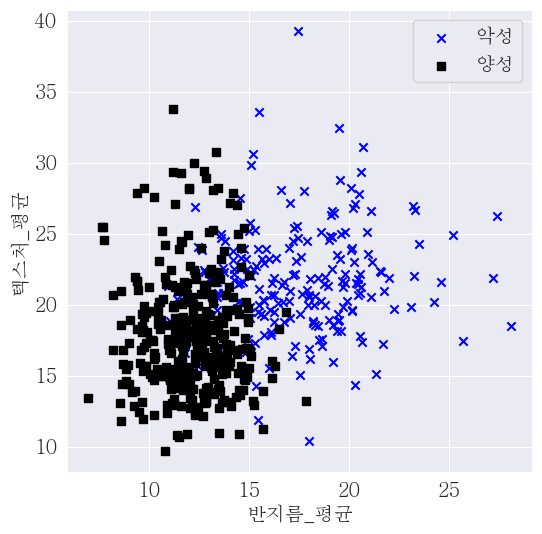

In [32]:
# 산점도 그리기
# 그래프의 크기를 설정
plt.figure(figsize=(6,6))

# 목적변수 값이 0인 데이터의 산점도 그리기
plt.scatter(df0['반지름_평균'], df0['텍스처_평균'], marker='x', c='b', label='악성')

# 목적변수 값이 1인 데이터의 산점도 그리기
plt.scatter(df1['반지름_평균'], df1['텍스처_평균'], marker='s', c='k', label='양성')

# 그리드 표시
plt.grid(True)

# 레이블 표시
plt.xlabel('반지름_평균')
plt.ylabel('텍스처_평균')

# 범례 그리기
plt.legend()

# 화면에 전체 그래프를 출력
plt.show()

In [33]:
# 출력된 산점도를 보면 예상한 내용 (반지름 평균의 값이 df0(악성 그룹)에서 더 큰 경향이 있다)이 맞았음을 알 수 있음.

In [34]:
# 4) 데이터 전처리

# 입력 데이터를 두 개의 필드로 줄이기
# 실제 데이터를 대상으로 모델을 만들 때 이 단계에서 큰 수고가 들지만
# 모델을 만들기 쉬운 데이터를 골랐기 때문에 입력 데이터를 두 가지로 줄이는 작업만 함

In [35]:
input_columns = ['반지름_평균', '텍스처_평균']
x = df[input_columns]
x.head()

,반지름_평균,텍스처_평균
0,17.9900,10.3800
1,20.5700,17.7700
2,19.6900,21.2500
3,11.4200,20.3800
4,20.2900,14.3400


In [36]:
# 5) 데이터 분할

# 데이터 분할에는
# 1) 목적 변수(정답 데이터)와 입력 변수(입력 데이터)를 분할 하는 것 (좌우 분할)과
# 2) 학습 데이터와 검증 데이터를 분할하는 것 (상하 분할) 두 가지가 있음
# 지금 데이터 집합은 데이터를 읽어 들였을 때 이미 목적 변수와 입력 변수가 나뉘어 있었으므로
# 좌우 분할은 생략하고 상하 분할만 구현

In [37]:
# 학습 데이터와 검증 데이터 분할하기
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, test_size=0.3, random_state=random_seed)

In [38]:
# train_test_split()
# * 원래 데이터의 x와 y를 각각 학습 데이터(train)와 검증 데이터(test)로 분할.
# * 분할된 데이터는 x_train, x_test, y_train, y_test 변수에 각각 대입.
# * 분할 비율은 train_size와 test_size 두 개의 인자에 지정할 수 있음.
#   여기서는 7:3으로 분할하기 위해 0.7과 0.3으로 두 인자의 값을 지정.
# * 데이터를 분할하기 전 원래 데이터를 무작위로 섞기 위해 난수를 사용.
#   무작위 섞기에 사용된 난수 시드의 값을 입력받는 파라미터가 random_state.
#   random_state값을 지정하면 항상 같은 결과가 나옴.

In [39]:
# 분할된 데이터를 확인하기(요소 수)

print(x_train.shape) #(398, 2)
print(x_test.shape) #(171, 2)
print(y_train.shape) #(398,)
print(y_test.shape) #(171,)

(398, 2)
(171, 2)
(398,)
(171,)


In [40]:
# 실행 결과를 보면 학습 데이터와 검증 데이터가 모두 7:3의 비율로 분할된 것을 확인

In [41]:
# 분할된 데이터를 확인하기(요소 수)
x_train.head()

,반지름_평균,텍스처_평균
559,11.5100,23.9300
295,13.7700,13.2700
264,17.1900,22.0700
125,13.8500,17.2100
280,19.1600,26.6000


In [42]:
y_train.head()

559    1
295    1
264    0
125    1
280    0
dtype: int64

In [43]:
x_test.head()

,반지름_평균,텍스처_평균
333,11.2500,14.7800
273,9.7420,15.6700
201,17.5400,19.3200
178,13.0100,22.2200
85,18.4600,18.5200


In [44]:
y_test.head()

333    1
273    1
201    0
178    1
85     0
dtype: int64

In [45]:
# 실행 결과를 보면 왼쪽 끝의 인덱스가 분할하기 전과 다르게 무작위로 섞였음을 알 수 있음

In [46]:
# 6) 알고리즘 선택하기

# LogisticRegression 로지스틱 회귀 (분류 알고리즘)를 사용

In [47]:
# 알고리즘 선택
from sklearn.linear_model import LogisticRegression
algorithm = LogisticRegression(random_state=random_seed) # 알고리즘 초기화

In [48]:
# 7) 학습

# 학습을 진행할 때는 만든 모델의 fit() 함수를 실행

In [49]:
algorithm.fit(x_train, y_train) # 첫 번째 인자는 표 형식으로 구성된 입력 데이터, 두 번째 인자는 입력 데이터와 대응하는 응답 데이터
algorithm

LogisticRegression(random_state=123)

In [50]:
algorithm.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 123,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [51]:
# 생성된 모델(algorithm)의 파라미터 값들을 출력
# random_state 외의 인자는 지정하지 않았기 때문에 그 외의 여러가지 인자가 기본값으로 설정

In [52]:
# 8) 예측

# 예측을 구현할 때는 예측 대상 입력 데이터가 표 형식으로 들어 있는 변수를 인자로 predict() 함수를 호출

In [53]:
# predict 함수를 호출한다
y_pred = algorithm.predict(x_test)
y_pred

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1])

In [54]:
# 9) 평가

# 검증 데이터를 대상으로 정답 데이터와 예측 결과가 얼마나 일치하는지 비교
# 정답 데이터와 예측 결과 비교하기

In [55]:
# 정답 데이터를 앞에서부터 10건 추려냄
# y_test는 데이터프레임이므로 value 속성에 담긴 넘파이 배열로 변환
y_test10 = y_test[:10].values
y_test10

array([1, 1, 0, 1, 0, 1, 1, 0, 1, 1])

In [56]:
# 예측 결과를 앞에서부터 10건 추려냄
y_pred10 = y_pred[:10]
y_pred10

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 1])

In [57]:
# 정답을 맞힌 건수 세기

# 정답 데이터 == 예측 결과
w1 = (y_test10 == y_pred10)
w1

array([ True,  True,  True,  True,  True,  True,  True, False,  True,
        True])

In [58]:
# 정답을 맞힌 건수
w2 = w1.sum()
w2

np.int64(9)

In [60]:
# 전체 데이터에 같은 방법을 적용
# 정확도 계산하기

# 정답을 맞힌 건수를 계산
w = (y_test.values == y_pred)
correct = w.sum()

# 검증 데이터 전체 건수
N = len(w)

# 정확도 = (정답 수) / (검증 데이터 전체 건수)
score = correct / N

# 결과를 출력
print(f'정확도: {score:.04f}') # 정확도: 08772

정확도: 0.8772


In [61]:
# 더 간단히 정확도를 측정하는 방법으로는 score() 함수를 사용

In [62]:
# score 함수를 사용해도 정확도를 계산할 수 있다
score = algorithm.score(x_test, y_test)
print(f'score: {score:.04f}')

score: 0.8772


In [63]:
# 10. 튜닝

In [64]:
# 원래 있던 30개 필드를 모두 포함해 학습 데이터와 검증 데이터를 다시 만듬
x2_train, x2_test, y_train, y_test = train_test_split(df, y, train_size=0.7, test_size=0.3, random_state=random_seed)

# 로지스틱 회귀를 이용한 매출 예측 모델도 다시 만듬
algorithm2 = LogisticRegression(random_state=random_seed)

# 새로 만든 학습 데이터로 학습을 진행
algorithm2.fit(x2_train, y_train)

# 검증 데이터로 정확도를 확인
score = algorithm2.score(x2_test, y_test)
print(f'score: {score:.04f}')

score: 0.9649
